In [41]:
# Sportsman Training Time Prediction using Decision Trees
# Dataset: gym_members_exercise_tracking.csv

In [42]:
import sys
print(sys.executable)

import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("sklearn ok:", sklearn.__version__)

/Users/andreitone/GitHub/Decision-Trees-Project/ID3/ID3/.venv/bin/python
sklearn ok: 1.8.0


In [43]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

In [44]:
df = pd.read_csv("gym_members_exercise_tracking.csv")
df.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [45]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape: (973, 15)

Columns:
 ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']

Missing values:
 Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

Data types:
 Age                                int64
Gender                               str
Weight (kg)                      float64
Height (m)                   

In [46]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


In [47]:
target = "Session_Duration (hours)"

In [48]:
def categorize_duration(x):
    if x < 1.0:
        return "Short"
    elif x < 1.5:
        return "Medium"
    else:
        return "Long"

df["Duration_Class"] = df["Session_Duration (hours)"].apply(categorize_duration)
df[["Session_Duration (hours)", "Duration_Class"]].head()

,Session_Duration (hours),Duration_Class
0,1.69,Long
1,1.30,Medium
2,1.11,Medium
3,0.59,Short
4,0.64,Short


In [49]:
df["Duration_Class"].value_counts()

Duration_Class
Medium    591
Long      196
Short     186
Name: count, dtype: int64

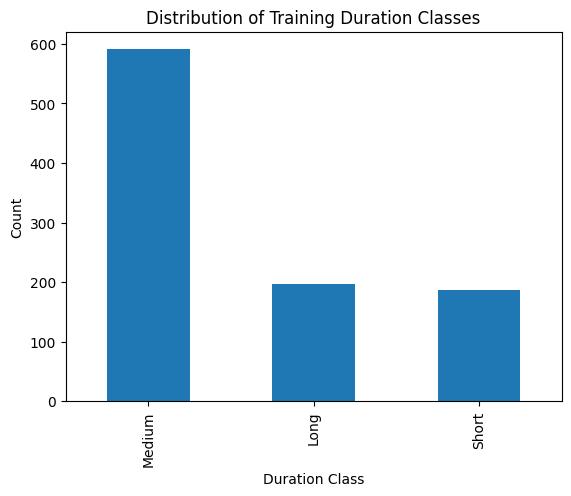

In [50]:
df["Duration_Class"].value_counts().plot(kind="bar")
plt.title("Distribution of Training Duration Classes")
plt.xlabel("Duration Class")
plt.ylabel("Count")
plt.show()

In [51]:
selected_features = [
    "Age",
    "Gender",
    "Avg_BPM",
    "Calories_Burned",
    "Workout_Type",
    "Workout_Frequency (days/week)",
    "Experience_Level",
    "BMI"
]

data = df[selected_features + ["Duration_Class"]].copy()
data.head()

,Age,Gender,Avg_BPM,Calories_Burned,Workout_Type,Workout_Frequency (days/week),Experience_Level,BMI,Duration_Class
0,56,Male,157,1313.0,Yoga,4,3,30.20,Long
1,46,Female,151,883.0,HIIT,4,2,32.00,Medium
2,32,Female,122,677.0,Cardio,4,2,24.71,Medium
3,25,Male,164,532.0,Strength,3,1,18.41,Short
4,38,Male,158,556.0,Strength,3,1,14.39,Short


In [52]:
data["Age"] = pd.cut(data["Age"], bins=3, labels=["Young", "Adult", "Older"])
data["Avg_BPM"] = pd.cut(data["Avg_BPM"], bins=3, labels=["Low_BPM", "Mid_BPM", "High_BPM"])
data["Calories_Burned"] = pd.cut(data["Calories_Burned"], bins=3, labels=["Low_Cal", "Mid_Cal", "High_Cal"])
data["BMI"] = pd.cut(data["BMI"], bins=3, labels=["Low_BMI", "Mid_BMI", "High_BMI"])
data["Workout_Frequency (days/week)"] = pd.cut(
    data["Workout_Frequency (days/week)"], bins=3, labels=["Low_Freq", "Mid_Freq", "High_Freq"]
)

data.head()

,Age,Gender,Avg_BPM,Calories_Burned,Workout_Type,Workout_Frequency (days/week),Experience_Level,BMI,Duration_Class
0,Older,Male,High_BPM,High_Cal,Yoga,Mid_Freq,3,Mid_BMI,Long
1,Older,Female,Mid_BPM,Mid_Cal,HIIT,Mid_Freq,2,Mid_BMI,Medium
2,Adult,Female,Low_BPM,Low_Cal,Cardio,Mid_Freq,2,Low_BMI,Medium
3,Young,Male,High_BPM,Low_Cal,Strength,Low_Freq,1,Low_BMI,Short
4,Adult,Male,High_BPM,Low_Cal,Strength,Low_Freq,1,Low_BMI,Short


In [53]:
encoders = {}
encoded_data = data.copy()

for col in encoded_data.columns:
    le = LabelEncoder()
    encoded_data[col] = le.fit_transform(encoded_data[col].astype(str))
    encoders[col] = le

encoded_data.head()

,Age,Gender,Avg_BPM,Calories_Burned,Workout_Type,Workout_Frequency (days/week),Experience_Level,BMI,Duration_Class
0,1,1,0,0,3,2,2,2,0
1,1,0,2,2,1,2,1,2,1
2,0,0,1,1,0,2,1,1,1
3,2,1,0,1,2,1,0,1,2
4,0,1,0,1,2,1,0,1,2


In [54]:
X = encoded_data.drop("Duration_Class", axis=1)
y = encoded_data["Duration_Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (778, 8)
X_test shape: (195, 8)


In [55]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

max_depth_values = [2, 3, 4, 5, 6, 8, 10, None]
depth_results = []

for depth in max_depth_values:
    model = DecisionTreeClassifier(
        criterion="entropy",
        splitter="best",
        max_depth=depth,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    depth_results.append({
        "max_depth": depth,
        "accuracy": accuracy_score(y_test, y_pred)
    })

pd.DataFrame(depth_results)

,max_depth,accuracy
0,2.0,0.841026
1,3.0,0.943590
2,4.0,0.943590
3,5.0,0.943590
4,6.0,0.943590
5,8.0,0.902564
6,10.0,0.876923
7,NaN,0.876923


In [56]:
min_samples_leaf_values = [1, 2, 4, 6, 8]
leaf_results = []

for leaf in min_samples_leaf_values:
    model = DecisionTreeClassifier(
        criterion="entropy",
        splitter="best",
        max_depth=4,
        min_samples_split=2,
        min_samples_leaf=leaf,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    leaf_results.append({
        "min_samples_leaf": leaf,
        "accuracy": accuracy_score(y_test, y_pred)
    })

pd.DataFrame(leaf_results)

,min_samples_leaf,accuracy
0,1,0.94359
1,2,0.94359
2,4,0.94359
3,6,0.94359
4,8,0.94359


In [57]:
min_samples_split_values = [2, 5, 10, 15, 20]
split_results = []

for split in min_samples_split_values:
    model = DecisionTreeClassifier(
        criterion="entropy",
        splitter="best",
        max_depth=4,
        min_samples_split=split,
        min_samples_leaf=1,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    split_results.append({
        "min_samples_split": split,
        "accuracy": accuracy_score(y_test, y_pred)
    })

pd.DataFrame(split_results)

,min_samples_split,accuracy
0,2,0.94359
1,5,0.94359
2,10,0.94359
3,15,0.94359
4,20,0.94359


In [58]:
id3_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=2,
    random_state=42
)

id3_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [59]:
y_pred = id3_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.841025641025641

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        39
           1       0.98      0.76      0.85       119
           2       0.55      0.97      0.71        37

    accuracy                           0.84       195
   macro avg       0.84      0.90      0.85       195
weighted avg       0.90      0.84      0.85       195


Confusion Matrix:

[[38  1  0]
 [ 0 90 29]
 [ 0  1 36]]


In [60]:
feature_names = X.columns.tolist()
class_names = encoders["Duration_Class"].classes_.tolist()

rules = export_text(id3_model, feature_names=feature_names)
print(rules)

|--- Experience_Level <= 1.50
|   |--- Calories_Burned <= 1.50
|   |   |--- class: 2
|   |--- Calories_Burned >  1.50
|   |   |--- class: 1
|--- Experience_Level >  1.50
|   |--- class: 0



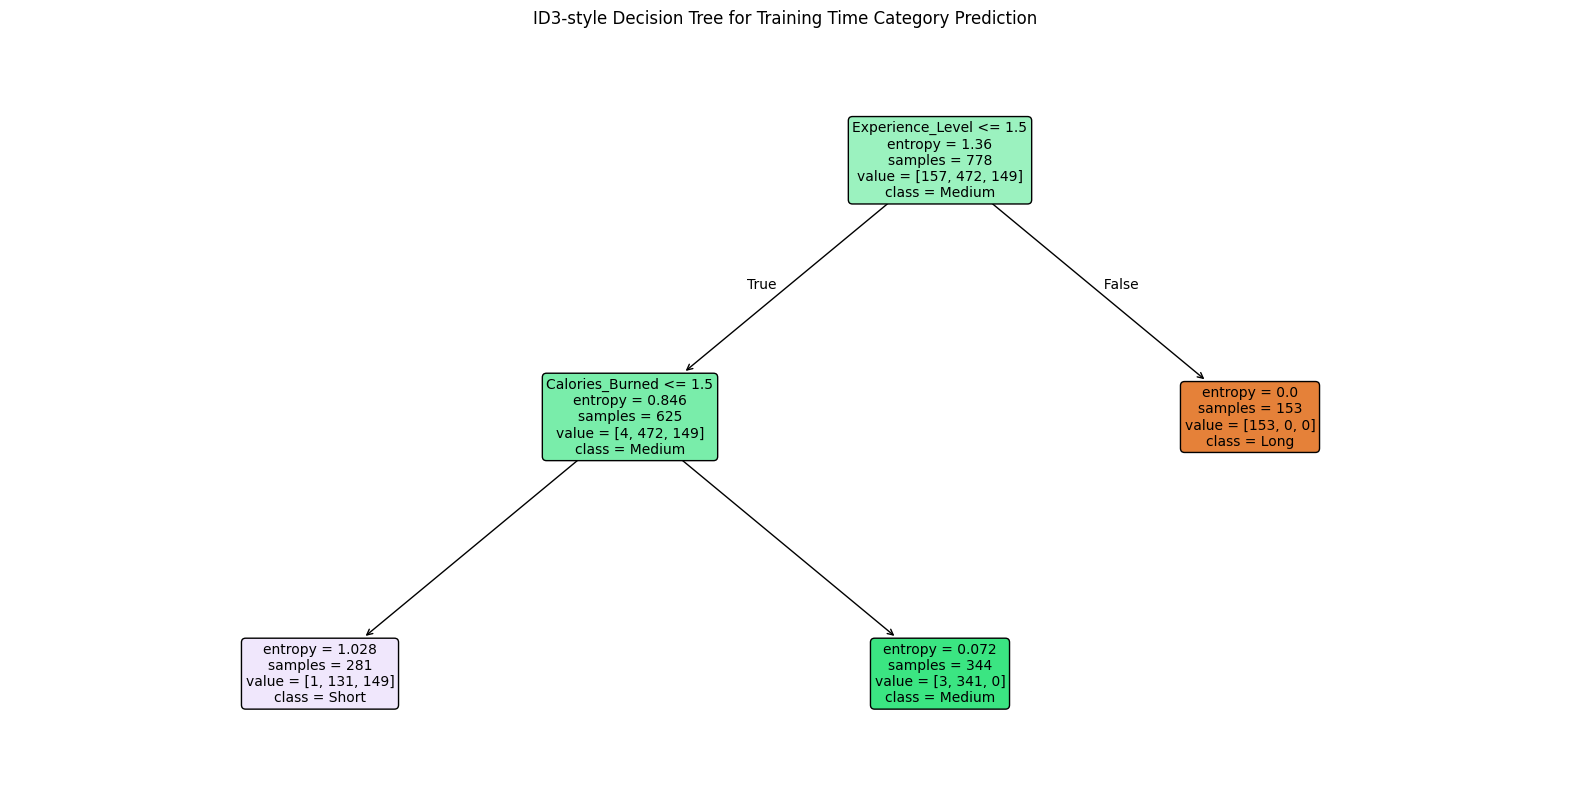

In [61]:
plt.figure(figsize=(20, 10))
plot_tree(
    id3_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("ID3-style Decision Tree for Training Time Category Prediction")
plt.show()

In [62]:
sample = pd.DataFrame([{
    "Age": "Adult",
    "Gender": "Male",
    "Avg_BPM": "High_BPM",
    "Calories_Burned": "High_Cal",
    "Workout_Type": "Cardio",
    "Workout_Frequency (days/week)": "High_Freq",
    "Experience_Level": "2",
    "BMI": "Mid_BMI"
}])

for col in sample.columns:
    sample[col] = encoders[col].transform(sample[col].astype(str))

prediction = id3_model.predict(sample)
predicted_label = encoders["Duration_Class"].inverse_transform(prediction)

print("Predicted training duration class:", predicted_label[0])

Predicted training duration class: Short
